In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                             auc, precision_recall_curve, average_precision_score, f1_score, accuracy_score)
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, precision_recall_curve
import joblib as jb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from fraud_detection.hyperparameter_tuning import get_hour
from fraud_detection.config import MODELS_DIR, PROJECT_ROOT, DATA_DIR, REPORTS_DIR
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
models = dict(
    xgb = jb.load(MODELS_DIR / "XGBoost_best_model.joblib")[0],
    xgb_smote = jb.load(MODELS_DIR / "XGBoost_smote_best_model.joblib")[0],
    rf = jb.load(MODELS_DIR / "RandomForest_best_model.joblib")[0],
    rf_smote = jb.load(MODELS_DIR / "RandomForest_smote_best_model.joblib")[0]
    )

scores = pd.Series(dict(
    xgb = jb.load(MODELS_DIR / "XGBoost_best_model.joblib")[1],
    xgb_smote = jb.load(MODELS_DIR / "XGBoost_smote_best_model.joblib")[1],
    rf = jb.load(MODELS_DIR / "RandomForest_best_model.joblib")[1],
    rf_smote = jb.load(MODELS_DIR / "RandomForest_smote_best_model.joblib")[1]
    ), name = 'AU-PRC Score')

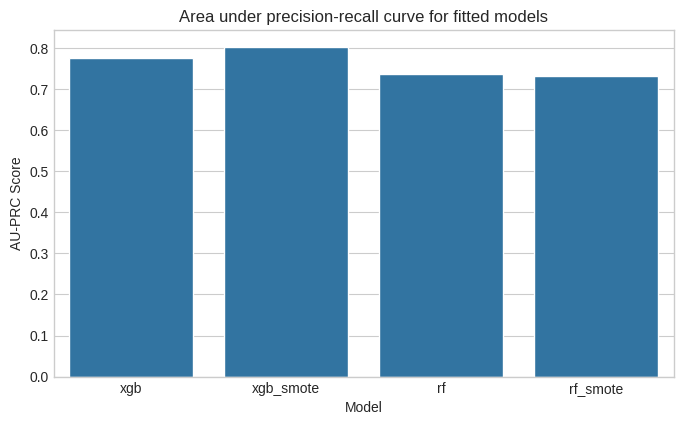

In [4]:
plt.figure(figsize=(8, 4.5))
sns.barplot(scores)
plt.title('Area under precision-recall curve for fitted models')
plt.xlabel('Model')
plt.savefig(REPORTS_DIR / 'evaluation_figures/au-prc-cv.png', bbox_inches='tight', facecolor='white')
plt.show()

We can see that using SMOTE oversampling yielded better results in training cross validation with both models, but the improvement is larger in the XGBoost model.

In [5]:
test = pd.read_csv(DATA_DIR / "test.csv")
X_test = test.drop(columns=["Class"])
y_test = test["Class"]

In [6]:
predictions = {name:model.predict(X_test) for name, model in models.items()}

In [7]:
classification_reports = {}
for name, preds in predictions.items():
    report = classification_report(y_test, preds, target_names = ['Non-Fraud', 'Fraud'], output_dict = True)
    classification_reports[name] = pd.DataFrame(report)

In [8]:
classification_reports['xgb']

,Non-Fraud,Fraud,accuracy,macro avg,weighted avg
precision,0.999649,0.958333,0.999607,0.978991,0.999594
recall,0.999958,0.734043,0.999607,0.867000,0.999607
f1-score,0.999803,0.831325,0.999607,0.915564,0.999581
support,71108.000000,94.000000,0.999607,71202.000000,71202.000000


In [9]:
classification_reports['rf']

,Non-Fraud,Fraud,accuracy,macro avg,weighted avg
precision,0.999677,0.780220,0.999396,0.889948,0.999387
recall,0.999719,0.755319,0.999396,0.877519,0.999396
f1-score,0.999698,0.767568,0.999396,0.883633,0.999391
support,71108.000000,94.000000,0.999396,71202.000000,71202.000000


Without SMOTE oversampling, the precision and f1-score is higher for the XGBoost model, however the recall is higher for the Random Forest model, which shows that the XGBoost model was more successful in predicting fraud correctly, however the Random Forest model was able to find a higher proportion of the actual fraud cases. In the fraud detection context, false negatives are usually more costly than false positives, so we may prioritise recall to catch as much fraud as possible.

In [10]:
classification_reports['xgb_smote']

,Non-Fraud,Fraud,accuracy,macro avg,weighted avg
precision,0.999691,0.837209,0.999494,0.918450,0.999476
recall,0.999803,0.765957,0.999494,0.882880,0.999494
f1-score,0.999747,0.800000,0.999494,0.899873,0.999483
support,71108.000000,94.000000,0.999494,71202.000000,71202.000000


In [11]:
classification_reports['rf_smote']

,Non-Fraud,Fraud,accuracy,macro avg,weighted avg
precision,0.999787,0.122671,0.991854,0.561229,0.998629
recall,0.992054,0.840426,0.991854,0.916240,0.991854
f1-score,0.995906,0.214092,0.991854,0.604999,0.994874
support,71108.000000,94.000000,0.991854,71202.000000,71202.000000


With SMOTE oversampling, the precision has fallen for both XGBoost and Random Forest, whereas the recall has grown for both.

In [12]:
for model, report in classification_reports.items():
    report.to_csv(REPORTS_DIR / f'evaluation_tables/{model}-classification-report.csv')

In [13]:
confusion_matrices = {name: confusion_matrix(y_test, preds) for name, preds in predictions.items()}

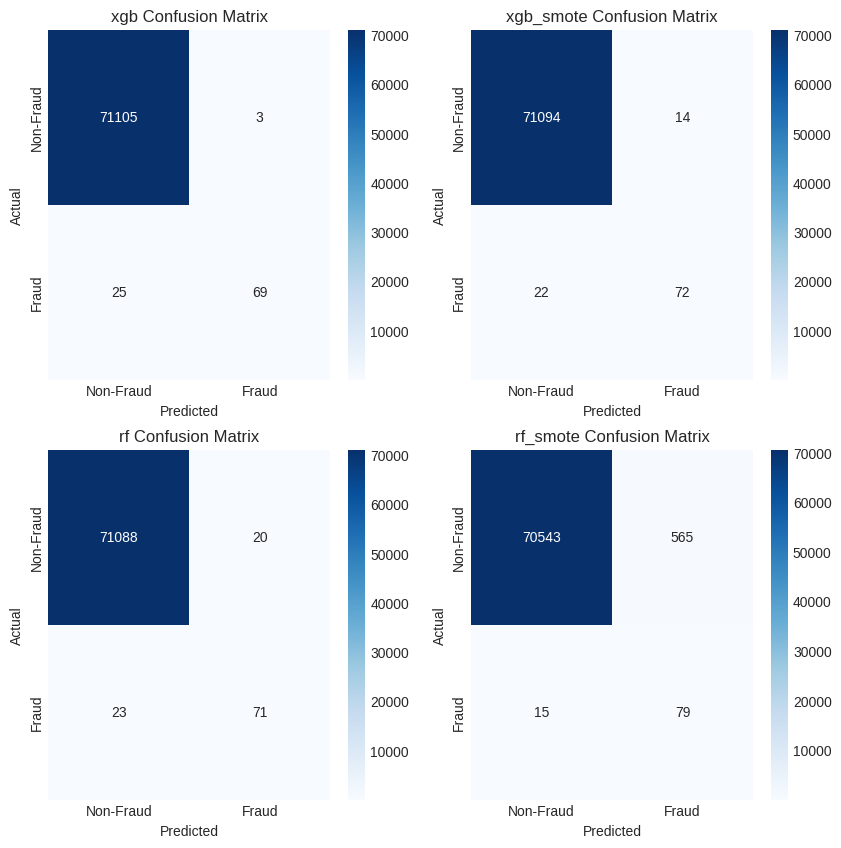

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))
for (name, matrix), ax in zip(confusion_matrices.items(), axs.flatten()):
    sns.heatmap(matrix, annot = True, fmt='d', cmap = "Blues", xticklabels=["Non-Fraud", "Fraud"], yticklabels=["Non-Fraud", "Fraud"], ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.savefig(REPORTS_DIR / f"evaluation_figures/confusion-matrices.png", bbox_inches='tight', facecolor='white')
plt.show()

In [15]:
probabilities = {name: model.predict_proba(X_test)[:, 1] for name, model in models.items()}

In [16]:
pr_curves = {name: precision_recall_curve(y_test, proba) for name, proba in probabilities.items()}

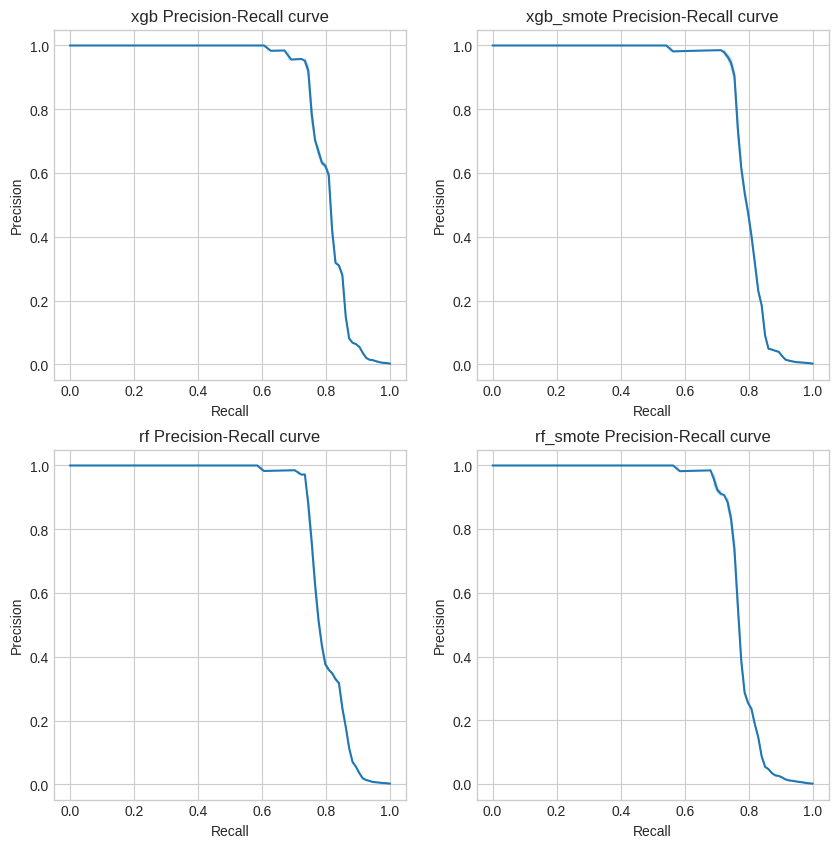

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))
for (name, pr_curve), ax in zip(pr_curves.items(), axs.flatten()):
    sns.lineplot(x=pr_curve[1], y=pr_curve[0], ax=ax)
    ax.set_title(f"{name} Precision-Recall curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
plt.savefig(REPORTS_DIR / f"evaluation_figures/pr-curves.png", bbox_inches='tight', facecolor='white')
plt.show()

In [24]:
au_prc = pd.Series({name: average_precision_score(y_test, proba) for name, proba in probabilities.items()})

au_prc

xgb          0.808942
xgb_smote    0.797723
rf           0.798224
rf_smote     0.776175
dtype: float64

When comparing the precision-recall curves, it is important to consider what level of precision is acceptable for the situation. False positives are costly for credit card companies as they waste resources investigaing, and it lowers customer satisfaction. Therefore, we can select a precision value of $0.8$ to check if the recall is sufficient at that point, and choose that threshold value for predictions.

In [20]:
target_precision = 0.8

for name, pr_curve in pr_curves.items():
    precision = pr_curve[0]
    recall = pr_curve[1]
    threshold = pr_curve[2]
    recall_at_target = recall[precision >= target_precision]
    if len(recall_at_target) > 0:
        recall_value = max(recall_at_target)
        index = np.where(recall == recall_value)
    else:
        recall_value = 0
    print(f"{name} Recall at precision ≥ {target_precision}: {recall_value:.4f} with threshold {max(threshold[index])}")

xgb Recall at precision ≥ 0.8: 0.7553 with threshold 0.15662774443626404
xgb_smote Recall at precision ≥ 0.8: 0.7660 with threshold 0.7063899636268616
rf Recall at precision ≥ 0.8: 0.7447 with threshold 0.668080642443712
rf_smote Recall at precision ≥ 0.8: 0.7553 with threshold 0.8339100579946419


Here, we will choose to use the XGBoost model without smote, as it has the highest area under the precision recall curve, so we can pick the threshold above where we achieve high recall and precision.